# Algorithm : Logistic Regression Classifier

## Target

### Predicting whether a motor insurance policyholder will file at least one claim during a policy year


In this notebook showcases applicatiion of **Logistic Regression** to find solutions for the problem stated..


**Target variable** (`Claim_Occurred`):
- **0** → No claim filed during the policy year
- **1** → At least one claim filed during the policy year

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, PolynomialFeatures
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [3]:
SEED = 42
np.random.seed(SEED)

In [4]:
DATA_PATH = "dataset/Motor vehicle insurance data.csv"

df = pd.read_csv(DATA_PATH, sep=';', low_memory=False)

print(f"Dataset shape : {df.shape}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")
print()
df.head()


Dataset shape : (105555, 30)
Rows          : 105,555
Columns       : 30



,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


## Exploratory Data Analysis

In [5]:
## Class distribution percentage
df['Claim_Occurred'] = (df['N_claims_year'] > 0).astype(int)

print("Target class distribution:")
claim_dist = df['Claim_Occurred'].value_counts()
claim_pct  = df['Claim_Occurred'].value_counts(normalize=True) * 100

print(pd.DataFrame({'Count': claim_dist, 'Percentage (%)': claim_pct.round(2)}).to_markdown())

Target class distribution:
|   Claim_Occurred |   Count |   Percentage (%) |
|-----------------:|--------:|-----------------:|
|                0 |   85909 |            81.39 |
|                1 |   19646 |            18.61 |


In [6]:
## Correlation with target 
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=['ID', 'N_claims_year', 'Cost_claims_year'], errors='ignore')

correlations = numeric_df.corr()['Claim_Occurred'].drop('Claim_Occurred').sort_values(key=abs, ascending=False)
print("\nTop 10 features by absolute correlation with Claim_Occurred:")
print(correlations.head(10).round(4).to_string())


Top 10 features by absolute correlation with Claim_Occurred:
R_Claims_history     0.5760
N_claims_history     0.2899
Payment              0.1162
Premium              0.1058
Policies_in_force    0.0920
Cylinder_capacity    0.0801
Power                0.0778
N_doors              0.0743
Weight               0.0737
Lapse               -0.0734


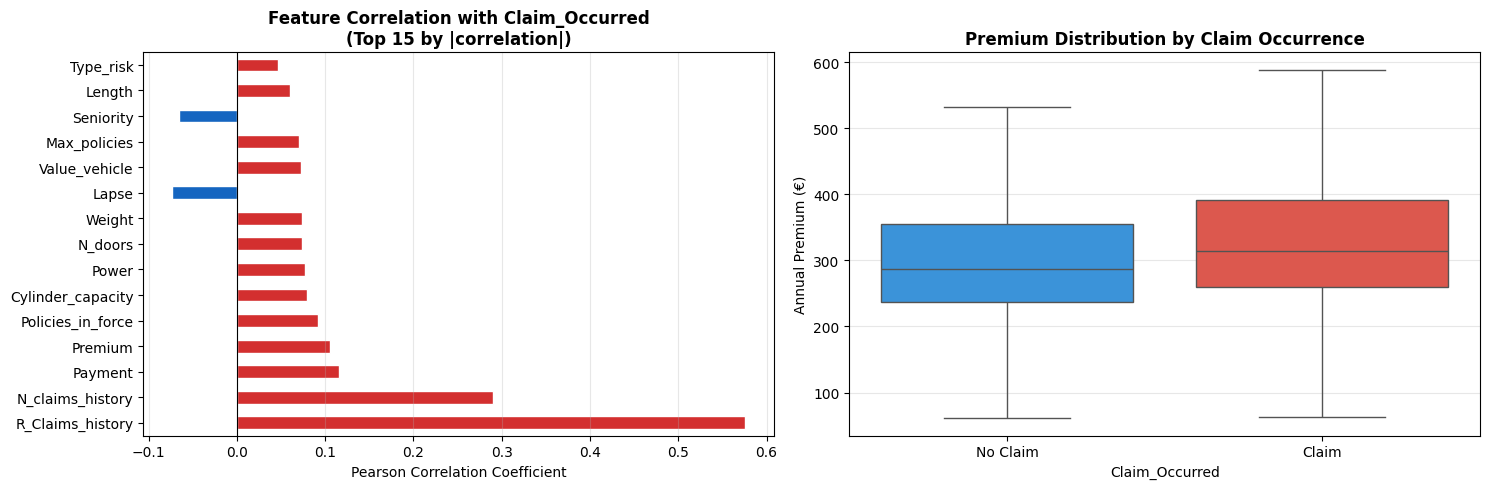

In [7]:
## Correlation Chart 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_corr = correlations.head(15)
colors_c = ['#D32F2F' if v > 0 else '#1565C0' for v in top_corr.values]
top_corr.plot(kind='barh', ax=axes[0], color=colors_c, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Feature Correlation with Claim_Occurred\n(Top 15 by |correlation|)', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation Coefficient')
axes[0].grid(axis='x', alpha=0.3)

## Premium distribution by claim
sns.boxplot(data=df, x='Claim_Occurred', y='Premium', ax=axes[1],
            palette=['#2196F3', '#F44336'],
            showfliers=False)
axes[1].set_xticklabels(['No Claim', 'Claim'])
axes[1].set_title('Premium Distribution by Claim Occurrence', fontweight='bold')
axes[1].set_ylabel('Annual Premium (€)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Feature Correlation Heatmap

As Logistic Regression is sensitive to multicollinearity, the correlation matrix will be inspected to identify highly correlated predictors.

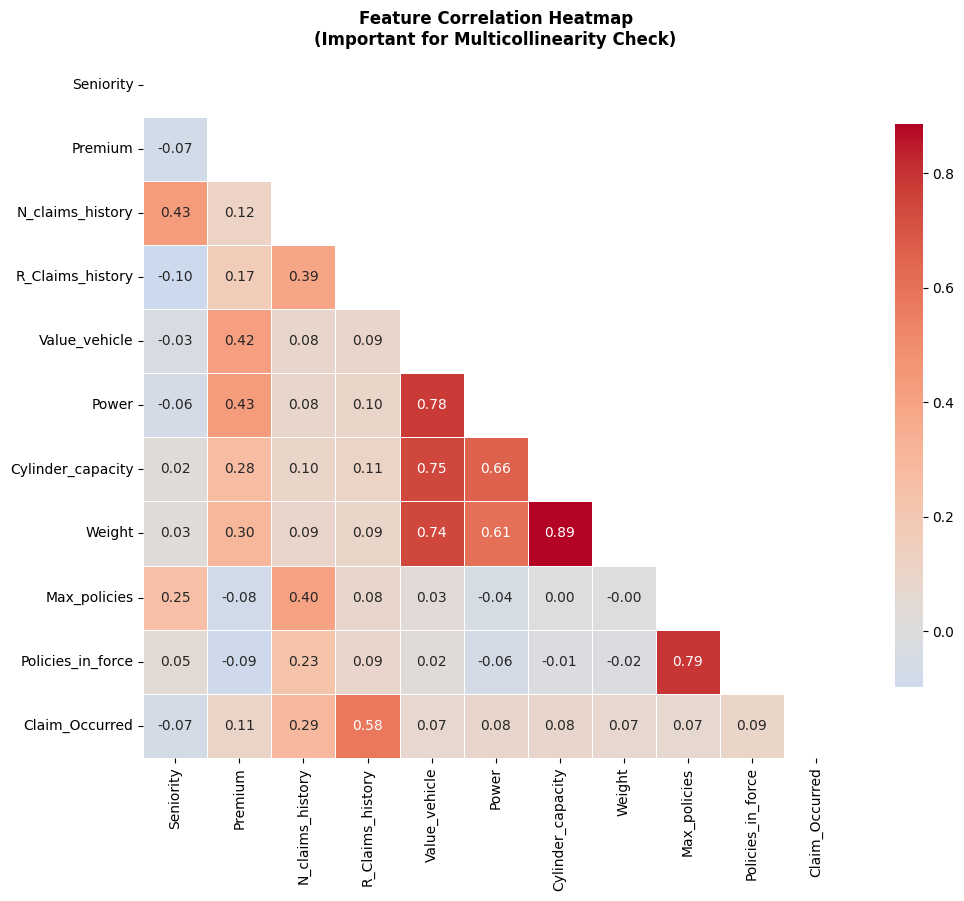

In [8]:
selected_cols = ['Seniority', 'Premium', 'N_claims_history', 'R_Claims_history',
                 'Value_vehicle', 'Power', 'Cylinder_capacity', 'Weight',
                 'Max_policies', 'Policies_in_force', 'Claim_Occurred']
corr_matrix = df[selected_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap\n(Important for Multicollinearity Check)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


Here high correlations (|r| > 0.8) will be addressed by dropping redundant features.

## Data Preprocessing

In [9]:
df_clean = df.copy()

In [10]:
##  Date columns parsing
date_cols = ['Date_start_contract', 'Date_last_renewal', 'Date_next_renewal',
             'Date_birth', 'Date_driving_licence', 'Date_lapse']
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], format='%d/%m/%Y', errors='coerce')

In [11]:
ref_date = pd.Timestamp('2020-01-01')
df_clean['Age_of_driver']      = ((ref_date - df_clean['Date_birth']).dt.days / 365.25).round(1)
df_clean['Driving_experience'] = ((ref_date - df_clean['Date_driving_licence']).dt.days / 365.25).round(1)
df_clean['Contract_duration']  = ((df_clean['Date_last_renewal'] - df_clean['Date_start_contract']).dt.days / 365.25).round(1)
df_clean['Vehicle_age']        = ref_date.year - df_clean['Year_matriculation']

In [12]:
## Column drop and Null handling
# Weight and Cylinder_capacity will be dropped die to high collinearity
# Cost_claims_year will be dropped due to data leakage
drop_cols = ['ID', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal',
             'Date_birth', 'Date_driving_licence', 'Date_lapse',
             'Cost_claims_year',   
             'N_claims_year',      
             'Year_matriculation', 
             'Cylinder_capacity',  
             'Weight']             

df_clean.drop(columns=drop_cols, inplace=True)

df_clean['Length'].fillna(df_clean['Length'].median(), inplace=True)
df_clean['Type_fuel'].fillna(df_clean['Type_fuel'].mode()[0], inplace=True)
df_clean['Age_of_driver'].fillna(df_clean['Age_of_driver'].median(), inplace=True)
df_clean['Driving_experience'].fillna(df_clean['Driving_experience'].median(), inplace=True)
df_clean['Contract_duration'].fillna(0, inplace=True)

In [13]:
df_clean.describe()

,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,N_claims_history,R_Claims_history,...,Second_driver,Power,Value_vehicle,N_doors,Length,Claim_Occurred,Age_of_driver,Driving_experience,Contract_duration,Vehicle_age
count,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,...,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000,105555.000000
mean,0.451310,6.696604,1.455649,1.837232,1.065842,0.221837,0.319180,315.892557,2.751760,0.425194,...,0.123708,92.682611,18413.657243,4.067898,4.249854,0.186121,49.860423,27.299900,2.981305,15.271962
std,0.497626,6.263911,0.928427,1.155536,0.267807,0.464858,0.466161,140.927969,3.881621,0.714883,...,0.329250,37.012645,9135.074235,1.511839,0.373543,0.389206,12.839755,12.486629,3.923487,6.767037
min,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,40.140000,0.000000,0.000000,...,0.000000,0.000000,270.460000,0.000000,1.978000,0.000000,19.200000,1.100000,-0.900000,2.000000
25%,0.000000,3.000000,1.000000,1.000000,1.000000,0.000000,0.000000,241.610000,0.000000,0.000000,...,0.000000,75.000000,13127.210000,3.000000,4.030000,0.000000,39.800000,16.900000,0.000000,12.000000
50%,0.000000,4.000000,1.000000,2.000000,1.000000,0.000000,0.000000,292.280000,1.000000,0.080000,...,0.000000,90.000000,17608.770000,5.000000,4.230000,0.000000,49.400000,26.500000,1.000000,15.000000
75%,1.000000,9.000000,2.000000,2.000000,1.000000,0.000000,1.000000,361.640000,4.000000,0.590000,...,0.000000,110.000000,22595.000000,5.000000,4.419000,0.000000,59.100000,36.700000,4.000000,19.000000
max,1.000000,40.000000,17.000000,17.000000,4.000000,7.000000,1.000000,2993.340000,52.000000,26.070000,...,1.000000,580.000000,220675.800000,6.000000,8.218000,1.000000,101.700000,77.300000,38.000000,70.000000


In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Distribution_channel  105555 non-null  int64  
 1   Seniority             105555 non-null  int64  
 2   Policies_in_force     105555 non-null  int64  
 3   Max_policies          105555 non-null  int64  
 4   Max_products          105555 non-null  int64  
 5   Lapse                 105555 non-null  int64  
 6   Payment               105555 non-null  int64  
 7   Premium               105555 non-null  float64
 8   N_claims_history      105555 non-null  int64  
 9   R_Claims_history      105555 non-null  float64
 10  Type_risk             105555 non-null  int64  
 11  Area                  105555 non-null  int64  
 12  Second_driver         105555 non-null  int64  
 13  Power                 105555 non-null  int64  
 14  Value_vehicle         105555 non-null  float64
 15  

In [15]:
## Categorical Encoding 

le = LabelEncoder()
df_clean['Type_fuel_enc'] = le.fit_transform(df_clean['Type_fuel'].astype(str))
df_clean.drop(columns=['Type_fuel'], inplace=True)

print(f"Remaining null values: {df_clean.isnull().sum().sum()}")
print(f"Final dataset shape  : {df_clean.shape}")
print()
features = [c for c in df_clean.columns if c != 'Claim_Occurred']
print(f"Features ({len(features)}):")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")


Remaining null values: 0
Final dataset shape  : (105555, 23)

Features (22):
   1. Distribution_channel
   2. Seniority
   3. Policies_in_force
   4. Max_policies
   5. Max_products
   6. Lapse
   7. Payment
   8. Premium
   9. N_claims_history
  10. R_Claims_history
  11. Type_risk
  12. Area
  13. Second_driver
  14. Power
  15. Value_vehicle
  16. N_doors
  17. Length
  18. Age_of_driver
  19. Driving_experience
  20. Contract_duration
  21. Vehicle_age
  22. Type_fuel_enc


## Dataset Splitting

In [16]:
X = df_clean.drop(columns=['Claim_Occurred'])
y = df_clean['Claim_Occurred']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training set  : {X_train.shape[0]:,} rows | {X_train.shape[1]} features")
print(f"Test set      : {X_test.shape[0]:,} rows  | {X_test.shape[1]} features")


Training set  : 84,444 rows | 22 features
Test set      : 21,111 rows  | 22 features


In [18]:
## Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled  = scaler.transform(X_test)         

In [19]:
## SMOTE -- Imbalance handling
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"\nClass distribution BEFORE SMOTE: {dict(pd.Series(y_train).value_counts())}")
print(f"Class distribution AFTER  SMOTE: {dict(pd.Series(y_train_bal).value_counts())}")
print(f"Balanced training set size: {X_train_bal.shape[0]:,}")



Class distribution BEFORE SMOTE: {0: np.int64(68727), 1: np.int64(15717)}
Class distribution AFTER  SMOTE: {0: np.int64(68727), 1: np.int64(68727)}
Balanced training set size: 137,454


## Model Training

In [20]:
lr_model = LogisticRegression(
    C            = 1.0,          
    penalty      = 'l2',         
    solver       = 'lbfgs',      
    max_iter     = 1000,         
    class_weight = 'balanced',   
    random_state = SEED
)

lr_model.fit(X_train_bal, y_train_bal)

print(f"Converged in n_iter_ : {lr_model.n_iter_[0]} iterations")


Converged in n_iter_ : 15 iterations


##  Hyperparameter Tuning (GridSearchCV on C)

In [21]:
param_grid = {'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

grid_search = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000,
                       class_weight='balanced', random_state=SEED),
    param_grid  = param_grid,
    cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring     = 'roc_auc',
    n_jobs      = -1,
    verbose     = 0
)

grid_search.fit(X_train_bal, y_train_bal)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]},
             scoring='roc_auc')

In [22]:
cv_results = pd.DataFrame(grid_search.cv_results_)
print("GridSearchCV Results (ROC-AUC by regularisation strength C):")
print(cv_results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_markdown())
print(f"\nBest C       : {grid_search.best_params_['C']}")
print(f"Best ROC-AUC : {grid_search.best_score_:.4f}")

GridSearchCV Results (ROC-AUC by regularisation strength C):
|    |   param_C |   mean_test_score |   std_test_score |
|---:|----------:|------------------:|-----------------:|
|  0 |     0.001 |            0.9277 |           0.0025 |
|  1 |     0.01  |            0.929  |           0.0026 |
|  2 |     0.1   |            0.9292 |           0.0026 |
|  3 |     1     |            0.9292 |           0.0026 |
|  4 |    10     |            0.9292 |           0.0026 |
|  5 |   100     |            0.9292 |           0.0026 |

Best C       : 100.0
Best ROC-AUC : 0.9292


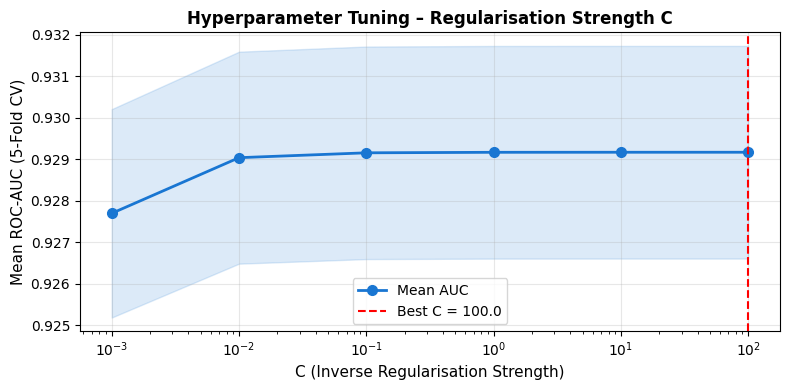

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
c_vals = [float(c) for c in cv_results['param_C']]
mean_scores = cv_results['mean_test_score'].values
std_scores  = cv_results['std_test_score'].values

ax.semilogx(c_vals, mean_scores, 'o-', color='#1976D2', lw=2, markersize=7, label='Mean AUC')
ax.fill_between(c_vals, mean_scores - std_scores, mean_scores + std_scores, alpha=0.15, color='#1976D2')
ax.axvline(grid_search.best_params_['C'], color='red', linestyle='--', lw=1.5,
           label=f"Best C = {grid_search.best_params_['C']}")
ax.set_xlabel('C (Inverse Regularisation Strength)', fontsize=11)
ax.set_ylabel('Mean ROC-AUC (5-Fold CV)', fontsize=11)
ax.set_title('Hyperparameter Tuning – Regularisation Strength C', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Use best model 
best_lr = grid_search.best_estimator_
print(f"\nBest model selected with C = {best_lr.C}")



Best model selected with C = 100.0


## Evaluation

In [25]:
y_pred      = best_lr.predict(X_test_scaled)
y_pred_prob = best_lr.predict_proba(X_test_scaled)[:, 1]


acc       = accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)
rec       = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)
avg_prec  = average_precision_score(y_test, y_pred_prob)

print("=" * 55)
print("LOGISTIC REGRESSION – TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy              : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision             : {prec:.4f}")
print(f"  Recall                : {rec:.4f}")
print(f"  F1 Score              : {f1:.4f}")
print(f"  ROC-AUC Score         : {roc_auc:.4f}")
print(f"  Avg Precision (PR-AUC): {avg_prec:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Claim', 'Claim']))


LOGISTIC REGRESSION – TEST SET RESULTS
  Accuracy              : 0.8761  (87.61%)
  Precision             : 0.6296
  Recall                : 0.8124
  F1 Score              : 0.7094
  ROC-AUC Score         : 0.9245
  Avg Precision (PR-AUC): 0.7166

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.95      0.89      0.92     17182
       Claim       0.63      0.81      0.71      3929

    accuracy                           0.88     21111
   macro avg       0.79      0.85      0.82     21111
weighted avg       0.89      0.88      0.88     21111



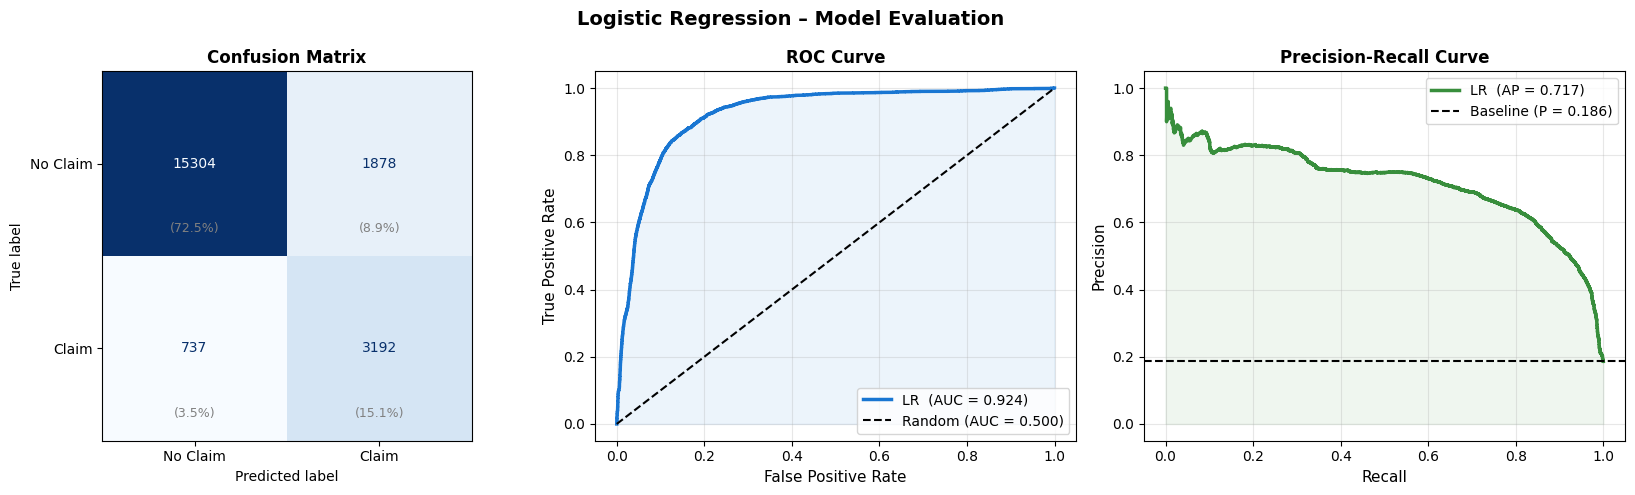

In [26]:
## Confusion Matrix, ROC Curve & Precision-Recall Curve

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Logistic Regression – Model Evaluation', fontsize=14, fontweight='bold')

## Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Claim', 'Claim'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')
total = cm.sum()
for i in range(2):
    for j in range(2):
        axes[0].text(j, i + 0.35, f'({cm[i,j]/total*100:.1f}%)',
                     ha='center', va='center', fontsize=9, color='grey')

## ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#1976D2', lw=2.5, label=f'LR  (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#1976D2')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

## Precision-Recall Curve
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_pred_prob)
axes[2].plot(rec_vals, prec_vals, color='#388E3C', lw=2.5, label=f'LR  (AP = {avg_prec:.3f})')
axes[2].axhline(y_test.mean(), color='k', linestyle='--', lw=1.5,
                label=f'Baseline (P = {y_test.mean():.3f})')
axes[2].fill_between(rec_vals, prec_vals, alpha=0.08, color='#388E3C')
axes[2].set_xlabel('Recall', fontsize=11)
axes[2].set_ylabel('Precision', fontsize=11)
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5-Fold Stratified Cross-Validation

In [27]:
from imblearn.pipeline import Pipeline as ImbPipeline

cv_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=SEED)),
    ('lr',     LogisticRegression(C=best_lr.C, penalty='l2', solver='lbfgs',
                                   max_iter=1000, class_weight='balanced',
                                   random_state=SEED))
])

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1  = cross_val_score(cv_pipeline, X, y, cv=skf, scoring='f1',       n_jobs=-1)
cv_auc = cross_val_score(cv_pipeline, X, y, cv=skf, scoring='roc_auc',  n_jobs=-1)
cv_acc = cross_val_score(cv_pipeline, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

cv_results_df = pd.DataFrame({
    'Fold'    : [f'Fold {i+1}' for i in range(5)],
    'Accuracy': cv_acc.round(4),
    'F1 Score': cv_f1.round(4),
    'ROC-AUC' : cv_auc.round(4)
})

print("5-Fold Stratified Cross-Validation Results (LR Pipeline):")
print(cv_results_df.to_string(index=False))
print()
print(f"Mean Accuracy  : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"Mean F1 Score  : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")
print(f"Mean ROC-AUC   : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")


5-Fold Stratified Cross-Validation Results (LR Pipeline):
  Fold  Accuracy  F1 Score  ROC-AUC
Fold 1    0.8719    0.7020   0.9215
Fold 2    0.8721    0.6982   0.9227
Fold 3    0.8700    0.6995   0.9216
Fold 4    0.8713    0.7001   0.9217
Fold 5    0.8736    0.7054   0.9271

Mean Accuracy  : 0.8718  ± 0.0012
Mean F1 Score  : 0.7010  ± 0.0025
Mean ROC-AUC   : 0.9229  ± 0.0021


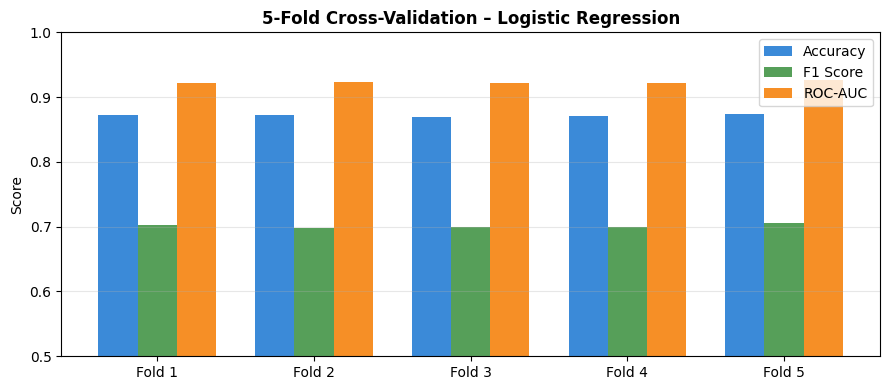

In [28]:
fig, ax = plt.subplots(figsize=(9, 4))
x     = np.arange(5)
width = 0.25
ax.bar(x - width, cv_acc,  width, label='Accuracy', color='#1976D2', alpha=0.85)
ax.bar(x,          cv_f1,  width, label='F1 Score',  color='#388E3C', alpha=0.85)
ax.bar(x + width,  cv_auc, width, label='ROC-AUC',   color='#F57C00', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0.5, 1.0)
ax.set_title('5-Fold Cross-Validation – Logistic Regression', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Coefficient Analysis (Model Interpretability)

- Positive coefficient → increases log-odds of a claim
- Negative coefficient → decreases log-odds of a claim

In [29]:
coefs = pd.Series(best_lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

print("Top 15 Most Influential Features (by |coefficient|):")
print(coefs.head(15).round(4).to_string())

Top 15 Most Influential Features (by |coefficient|):
R_Claims_history      2.5672
Lapse                -0.9181
Policies_in_force     0.3073
N_claims_history      0.2762
Contract_duration    -0.2633
Max_policies         -0.2059
Seniority             0.1515
N_doors               0.1315
Premium              -0.0896
Payment               0.0503
Type_risk             0.0490
Driving_experience    0.0457
Value_vehicle        -0.0450
Age_of_driver        -0.0373
Max_products         -0.0287


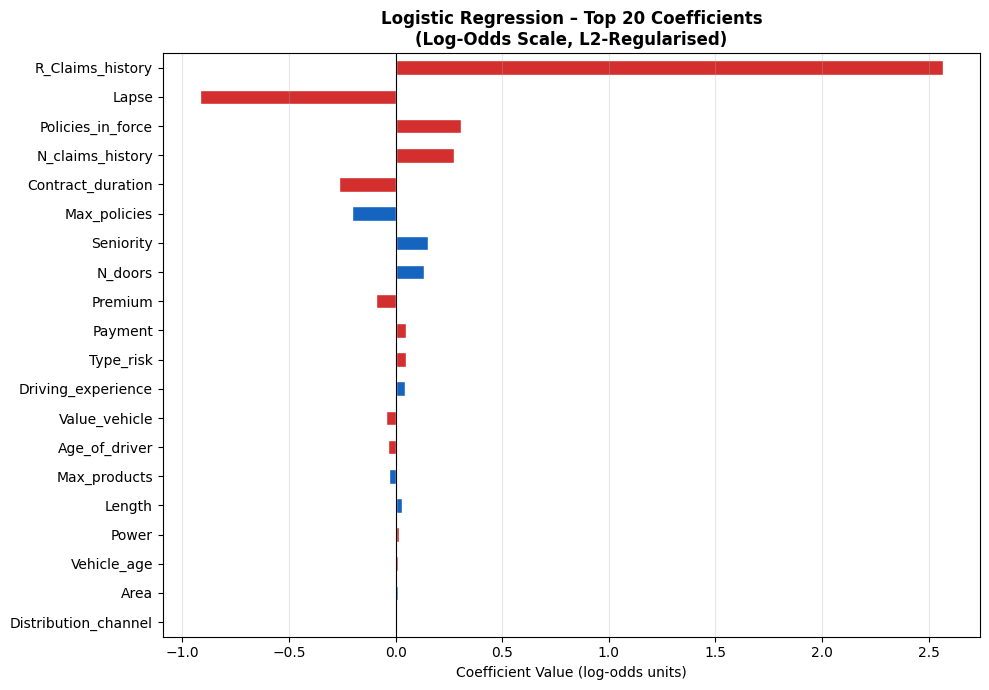

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))
colors_coef = ['#D32F2F' if v > 0 else '#1565C0' for v in coefs.values[:20]]
coefs.head(20).plot(kind='barh', ax=ax, color=colors_coef[::-1], edgecolor='white')
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic Regression – Top 20 Coefficients\n(Log-Odds Scale, L2-Regularised)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Coefficient Value (log-odds units)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()